In [1]:
# ============================================================
# SGMSE+ Notebook - Hücre 1
# A100 / GPU kontrolü
# ============================================================

!nvidia-smi

import torch

print("CUDA kullanılabilir mi?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU adı:", torch.cuda.get_device_name(0))
    print("CUDA sürümü:", torch.version.cuda)
else:
    print("GPU bulunamadı.")

Sat May 30 07:56:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# ============================================================
# SGMSE+ Notebook - Hücre 2
# Drive bağlama ve klasör yapısı
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/SLESS_SGMSE_PLUS")

CLEAN_DIR = BASE_DIR / "data" / "clean_16k"
NOISE_DIR = BASE_DIR / "data" / "noise_16k"

MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"
OUT_DIR = BASE_DIR / "outputs"

for d in [CLEAN_DIR, NOISE_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Klasörler hazır:")
for d in [BASE_DIR, CLEAN_DIR, NOISE_DIR, MODEL_DIR, LOG_DIR, OUT_DIR]:
    print(d)

Mounted at /content/drive
Klasörler hazır:
/content/drive/MyDrive/SLESS_SGMSE_PLUS
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/clean_16k
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/noise_16k
/content/drive/MyDrive/SLESS_SGMSE_PLUS/models
/content/drive/MyDrive/SLESS_SGMSE_PLUS/logs
/content/drive/MyDrive/SLESS_SGMSE_PLUS/outputs


In [3]:
# ============================================================
# SGMSE+ Notebook - Hücre 3
# Gerekli paketlerin kurulumu
# ============================================================

!pip install -q \
torchinfo \
pesq \
pystoi \
librosa \
soundfile \
datasets \
transformers \
accelerate

print("✅ Paket kurulumları tamamlandı")

  Preparing metadata (setup.py) ... done
✅ Paket kurulumları tamamlandı


In [16]:
# ============================================================
# SGMSE+ Notebook - Hücre 4
# Importlar + CFG ayarları
# Kalite odaklı final ayarlar
# ============================================================

import os
import gc
import json
import math
import random
import shutil
import warnings

import numpy as np
import pandas as pd

import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from pesq import pesq
from pystoi.stoi import stoi

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG = {
    "sample_rate": 16000,

    "n_fleurs": 2000,
    "n_cv": 12000,

    "noise_files": 659,

    "segment_seconds": 4.0,
    "segment_samples": int(16000 * 4.0),

    "snr_min": -5,
    "snr_max": 20,

    # Kalite odaklı ayarlar
    "batch_size": 8,
    "epochs": 40,
    "learning_rate": 5e-5,
    "grad_accum_steps": 2,

    "num_workers": 0,

    "train_ratio": 0.9,
    "val_ratio": 0.1,

    "eval_items": 200,

    "dns_noise_source": "/content/drive/MyDrive/noise"
}

print("✅ Importlar ve ayarlar hazır")
print("DEVICE:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print("\nCFG:")
print(json.dumps(CFG, indent=2))

✅ Importlar ve ayarlar hazır
DEVICE: cuda
GPU: NVIDIA A100-SXM4-80GB

CFG:
{
  "sample_rate": 16000,
  "n_fleurs": 2000,
  "n_cv": 12000,
  "noise_files": 659,
  "segment_seconds": 4.0,
  "segment_samples": 64000,
  "snr_min": -5,
  "snr_max": 20,
  "batch_size": 8,
  "epochs": 40,
  "learning_rate": 5e-05,
  "grad_accum_steps": 2,
  "num_workers": 0,
  "train_ratio": 0.9,
  "val_ratio": 0.1,
  "eval_items": 200,
  "dns_noise_source": "/content/drive/MyDrive/noise"
}


In [5]:
# ============================================================
# SGMSE+ Notebook - Hücre 5
# Ses yardımcı fonksiyonları
# ============================================================

def peak_normalize(audio, peak=0.9, eps=1e-8):
    audio = np.asarray(audio, dtype=np.float32).reshape(-1)

    if audio.size == 0:
        return None

    max_val = np.max(np.abs(audio))

    if max_val < eps:
        return None

    audio = audio / max_val * peak

    return audio.astype(np.float32)


def write_wav(path, audio, sr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    audio = np.asarray(audio, dtype=np.float32).reshape(-1)
    audio = np.nan_to_num(audio)

    sf.write(str(path), audio, sr)


def load_wav_any(path, target_sr=16000):
    try:
        audio, sr = librosa.load(str(path), sr=target_sr, mono=True)
        audio = np.asarray(audio, dtype=np.float32).reshape(-1)

        if audio.size == 0:
            return None

        if not np.isfinite(audio).all():
            return None

        return audio

    except Exception:
        return None


def load_hf_audio(item, target_sr=16000):
    try:
        audio_obj = item.get("audio", None)

        if audio_obj is None:
            return None

        if hasattr(audio_obj, "get_all_samples"):
            samples = audio_obj.get_all_samples()
            arr = samples.data

            if hasattr(arr, "numpy"):
                arr = arr.numpy()

            sr = samples.sample_rate

        elif isinstance(audio_obj, dict):
            arr = audio_obj.get("array", None)
            sr = audio_obj.get("sampling_rate", None)

        else:
            return None

        if arr is None or sr is None:
            return None

        arr = np.asarray(arr, dtype=np.float32).reshape(-1)

        if arr.size == 0:
            return None

        if sr != target_sr:
            arr = librosa.resample(
                arr,
                orig_sr=sr,
                target_sr=target_sr
            )

        arr = peak_normalize(arr, 0.9)

        return arr

    except Exception:
        return None


def fix_length(audio, length):
    audio = np.asarray(audio, dtype=np.float32).reshape(-1)

    if audio.size == 0:
        audio = np.zeros(length, dtype=np.float32)

    if len(audio) > length:
        start = random.randint(0, len(audio) - length)
        return audio[start:start + length].astype(np.float32)

    if len(audio) < length:
        pad = length - len(audio)
        return np.pad(audio, (0, pad), mode="constant").astype(np.float32)

    return audio.astype(np.float32)


def mix_with_snr(clean, noise, snr_db):
    clean = np.asarray(clean, dtype=np.float32).reshape(-1)
    noise = np.asarray(noise, dtype=np.float32).reshape(-1)

    if clean.size == 0:
        clean = np.zeros(CFG["segment_samples"], dtype=np.float32)

    if noise.size == 0:
        noise = np.random.randn(clean.size).astype(np.float32) * 0.01

    if len(noise) < len(clean):
        repeat = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeat)

    noise = noise[:len(clean)]

    clean_power = np.mean(clean ** 2) + 1e-8
    noise_power = np.mean(noise ** 2) + 1e-8

    target_noise_power = clean_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)

    noisy = clean + noise * scale

    max_val = np.max(np.abs(noisy)) + 1e-8

    if max_val > 1.0:
        noisy = noisy / max_val * 0.99
        clean = clean / max_val * 0.99

    return noisy.astype(np.float32).reshape(-1), clean.astype(np.float32).reshape(-1)


def safe_load_audio(path, sr):
    audio = load_wav_any(path, sr)

    if audio is None:
        return None

    audio = np.asarray(audio, dtype=np.float32).reshape(-1)

    if audio.size < sr:
        return None

    if not np.isfinite(audio).all():
        return None

    audio = peak_normalize(audio, 0.9)

    if audio is None:
        return None

    return audio.astype(np.float32).reshape(-1)


print("✅ Ses yardımcı fonksiyonları hazır")

✅ Ses yardımcı fonksiyonları hazır


In [6]:
# ============================================================
# SGMSE+ Notebook - Hücre 6
# Drive'daki DNS noise klasörünü kontrol etme
# ============================================================

DNS_SOURCE_DIR = Path(CFG["dns_noise_source"])

print("DNS noise klasörü var mı?:", DNS_SOURCE_DIR.exists())
print("DNS noise yolu:", DNS_SOURCE_DIR)

dns_files = []

for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
    dns_files.extend(DNS_SOURCE_DIR.rglob(ext))

dns_files = sorted(dns_files)

print("Bulunan gerçek noise dosyası:", len(dns_files))

print("\nİlk 10 noise dosyası:")
for f in dns_files[:10]:
    print(f)

if len(dns_files) == 0:
    raise RuntimeError("DNS noise klasöründe audio dosyası bulunamadı.")
else:
    print("\n✅ DNS noise klasörü hazır.")

DNS noise klasörü var mı?: True
DNS noise yolu: /content/drive/MyDrive/noise
Bulunan gerçek noise dosyası: 659

İlk 10 noise dosyası:
/content/drive/MyDrive/noise/extracted/noise/0CaA0wAIbKc.wav
/content/drive/MyDrive/noise/extracted/noise/0LnYEuBp6uU.wav
/content/drive/MyDrive/noise/extracted/noise/0Lpb1lba5yY.wav
/content/drive/MyDrive/noise/extracted/noise/0LqI1bux4Ow.wav
/content/drive/MyDrive/noise/extracted/noise/0LrTnI-BYSI.wav
/content/drive/MyDrive/noise/extracted/noise/0LvBAEYGpsA.wav
/content/drive/MyDrive/noise/extracted/noise/0hAK5f1tDok.wav
/content/drive/MyDrive/noise/extracted/noise/0lq5Oey7ChY.wav
/content/drive/MyDrive/noise/extracted/noise/0ls9KaQJAs0.wav
/content/drive/MyDrive/noise/extracted/noise/0lsf6jybC0M.wav

✅ DNS noise klasörü hazır.


In [7]:
# ============================================================
# SGMSE+ Notebook - Hücre 7
# DNS noise subset hazırlama
# ============================================================

def prepare_dns_noise_subset(source_dir, target_dir, n_max, sr):

    target_dir.mkdir(parents=True, exist_ok=True)

    existing = sorted(target_dir.glob("dns_noise_*.wav"))

    if len(existing) >= min(n_max, len(dns_files)):
        print(f"✅ DNS subset zaten hazır: {len(existing)} dosya")
        return existing

    source_files = []

    for ext in ["*.wav", "*.flac", "*.mp3", "*.ogg"]:
        source_files.extend(Path(source_dir).rglob(ext))

    source_files = sorted(source_files)
    random.Random(SEED).shuffle(source_files)
    source_files = source_files[:min(n_max, len(source_files))]

    saved = []
    failed = 0

    pbar = tqdm(source_files, desc="DNS noise hazırlanıyor")

    for idx, src in enumerate(pbar):

        audio = safe_load_audio(src, sr)

        if audio is None:
            failed += 1
            continue

        audio = peak_normalize(audio, 0.8)

        if audio is None:
            failed += 1
            continue

        out_path = target_dir / f"dns_noise_{idx:05d}.wav"

        write_wav(out_path, audio, sr)

        saved.append(out_path)

        pbar.set_postfix({
            "saved": len(saved),
            "failed": failed
        })

    print(f"\n✅ Hazırlanan DNS noise: {len(saved)}")
    print(f"❌ Atlanan: {failed}")

    return saved


noise_paths = prepare_dns_noise_subset(
    DNS_SOURCE_DIR,
    NOISE_DIR,
    CFG["noise_files"],
    CFG["sample_rate"]
)

print("\nKullanılacak noise dosyası:", len(noise_paths))

print("\nİlk 5 subset noise:")
for p in noise_paths[:5]:
    print(p)

DNS noise hazırlanıyor:   0%|          | 0/659 [00:00<?, ?it/s]


✅ Hazırlanan DNS noise: 659
❌ Atlanan: 0

Kullanılacak noise dosyası: 659

İlk 5 subset noise:
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/noise_16k/dns_noise_00000.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/noise_16k/dns_noise_00001.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/noise_16k/dns_noise_00002.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/noise_16k/dns_noise_00003.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/noise_16k/dns_noise_00004.wav


In [8]:
# ============================================================
# MetricGAN+ Notebook - Hücre 8
# Türkçe temiz sesleri hazırlama
# FLEURS + CommonVoice17
# ============================================================

def save_clean_batch(source_name, items, n_max, target_dir):

    saved = 0
    failed = 0

    pbar = tqdm(
        items[:n_max],
        desc=f"{source_name} kaydediliyor"
    )

    for idx, item in enumerate(pbar):

        audio = load_hf_audio(
            item,
            CFG["sample_rate"]
        )

        if audio is None:
            failed += 1
            continue

        out_path = (
            target_dir /
            f"{source_name}_{idx:06d}.wav"
        )

        write_wav(
            out_path,
            audio,
            CFG["sample_rate"]
        )

        saved += 1

        pbar.set_postfix({
            "saved": saved,
            "failed": failed
        })

    print(
        f"✅ {source_name}: "
        f"{saved} kayıt, "
        f"{failed} atlandı"
    )


# ------------------------------------------------------------
# FLEURS
# ------------------------------------------------------------

print("📥 FLEURS tr_tr indiriliyor...")

fleurs_train = load_dataset(
    "google/fleurs",
    "tr_tr",
    split="train"
)

fleurs_val = load_dataset(
    "google/fleurs",
    "tr_tr",
    split="validation"
)

fleurs_test = load_dataset(
    "google/fleurs",
    "tr_tr",
    split="test"
)

print("FLEURS train:", len(fleurs_train))
print("FLEURS validation:", len(fleurs_val))
print("FLEURS test:", len(fleurs_test))

fleurs_all = list(fleurs_train)

random.Random(SEED).shuffle(fleurs_all)

save_clean_batch(
    "fleurs",
    fleurs_all,
    CFG["n_fleurs"],
    CLEAN_DIR
)

# ------------------------------------------------------------
# CommonVoice17 TR
# ------------------------------------------------------------

print("📥 CommonVoice17 TR indiriliyor...")

cv_train = load_dataset(
    "fixie-ai/common_voice_17_0",
    "tr",
    split="train"
)

print("CV17 train:", len(cv_train))

cv_all = list(cv_train)

random.Random(SEED).shuffle(cv_all)

save_clean_batch(
    "cv17",
    cv_all,
    CFG["n_cv"],
    CLEAN_DIR
)

# ------------------------------------------------------------
# Son kontrol
# ------------------------------------------------------------

all_clean = sorted(
    CLEAN_DIR.glob("*.wav")
)

print("\nToplam temiz Türkçe ses:", len(all_clean))

print("\nİlk 5 temiz ses:")
for p in all_clean[:5]:
    print(p)

📥 FLEURS tr_tr indiriliyor...


README.md:   0%|          | 0.00/386k [00:00<?, ?B/s]

parquet-data/tr_tr/train-00000-of-00001.(…):   0%|          | 0.00/1.90G [00:00<?, ?B/s]

parquet-data/tr_tr/validation-00000-of-0(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

parquet-data/tr_tr/test-00000-of-00001.p(…):   0%|          | 0.00/590M [00:00<?, ?B/s]

...

Generating invalidated split:   0%|          | 0/4530 [00:00<?, ? examples/s]

Generating validated split:   0%|          | 0/114056 [00:00<?, ? examples/s]

CV17 train: 35147


cv17 kaydediliyor:   0%|          | 0/12000 [00:00<?, ?it/s]

✅ cv17: 12000 kayıt, 0 atlandı

Toplam temiz Türkçe ses: 14000

İlk 5 temiz ses:
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/clean_16k/cv17_000000.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/clean_16k/cv17_000001.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/clean_16k/cv17_000002.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/clean_16k/cv17_000003.wav
/content/drive/MyDrive/SLESS_SGMSE_PLUS/data/clean_16k/cv17_000004.wav


In [9]:
# ============================================================
# MetricGAN+ Notebook - Hücre 9
# Dataset + DataLoader
# ============================================================

class TurkishSpeechDataset(Dataset):

    def __init__(self, clean_files, noise_files):

        self.clean_files = clean_files
        self.noise_files = noise_files

    def __len__(self):
        return len(self.clean_files)

    def __getitem__(self, idx):

        clean_path = self.clean_files[idx]

        clean = safe_load_audio(
            clean_path,
            CFG["sample_rate"]
        )

        clean = fix_length(
            clean,
            CFG["segment_samples"]
        )

        noise_path = random.choice(
            self.noise_files
        )

        noise = safe_load_audio(
            noise_path,
            CFG["sample_rate"]
        )

        noise = fix_length(
            noise,
            CFG["segment_samples"]
        )

        snr = random.uniform(
            CFG["snr_min"],
            CFG["snr_max"]
        )

        noisy, clean = mix_with_snr(
            clean,
            noise,
            snr
        )

        return (
            torch.tensor(noisy),
            torch.tensor(clean)
        )


all_clean = sorted(
    CLEAN_DIR.glob("*.wav")
)

random.Random(SEED).shuffle(all_clean)

split_idx = int(
    len(all_clean) *
    CFG["train_ratio"]
)

train_clean = all_clean[:split_idx]
val_clean = all_clean[split_idx:]

print("Toplam clean:", len(all_clean))
print("Train clean:", len(train_clean))
print("Val clean:", len(val_clean))
print("Noise:", len(noise_paths))

train_ds = TurkishSpeechDataset(
    train_clean,
    noise_paths
)

val_ds = TurkishSpeechDataset(
    val_clean,
    noise_paths
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    drop_last=False
)

print("Train batch:", len(train_loader))
print("Val batch:", len(val_loader))

noisy_batch, clean_batch = next(iter(train_loader))

print("Noisy batch shape:", noisy_batch.shape)
print("Clean batch shape:", clean_batch.shape)

print(
    "Noisy finite:",
    torch.isfinite(noisy_batch).all().item()
)

print(
    "Clean finite:",
    torch.isfinite(clean_batch).all().item()
)

Toplam clean: 14000
Train clean: 12600
Val clean: 1400
Noise: 659
Train batch: 1575
Val batch: 175
Noisy batch shape: torch.Size([8, 64000])
Clean batch shape: torch.Size([8, 64000])
Noisy finite: True
Clean finite: True


In [17]:
# ============================================================
# SGMSE+ Notebook - Hücre 10
# SGMSE+ benzeri score-based spectrogram enhancement modeli
# ============================================================

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.dim = dim

        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half = self.dim // 2

        freqs = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=t.device).float() /
            half
        )

        args = t[:, None] * freqs[None, :]

        emb = torch.cat(
            [torch.sin(args), torch.cos(args)],
            dim=-1
        )

        if emb.shape[-1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))

        return self.mlp(emb)


class ResBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)

        self.time_proj = nn.Linear(time_dim, out_ch)

        if in_ch != out_ch:
            self.skip = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()

        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.act(h)

        time = self.time_proj(t_emb)
        h = h + time[:, :, None, None]

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.act(h)

        return h + self.skip(x)


class SGMSEPlusNet(nn.Module):
    def __init__(self, n_fft=512, hop_length=128, base_ch=48, time_dim=128):
        super().__init__()

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = n_fft

        self.time_emb = TimeEmbedding(time_dim)

        # input kanalları:
        # noisy real, noisy imag, perturbed real, perturbed imag = 4 kanal
        self.in_proj = nn.Conv2d(4, base_ch, 3, padding=1)

        self.enc1 = ResBlock2D(base_ch, base_ch, time_dim)
        self.down1 = nn.Conv2d(base_ch, base_ch * 2, 4, stride=2, padding=1)

        self.enc2 = ResBlock2D(base_ch * 2, base_ch * 2, time_dim)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 4, 4, stride=2, padding=1)

        self.mid1 = ResBlock2D(base_ch * 4, base_ch * 4, time_dim)
        self.mid2 = ResBlock2D(base_ch * 4, base_ch * 4, time_dim)

        self.up1 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, stride=2, padding=1)
        self.dec1 = ResBlock2D(base_ch * 4, base_ch * 2, time_dim)

        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, stride=2, padding=1)
        self.dec2 = ResBlock2D(base_ch * 2, base_ch, time_dim)

        # output: clean real + clean imag tahmini
        self.out = nn.Conv2d(base_ch, 2, 3, padding=1)

    def stft(self, waveform):
        window = torch.hann_window(
            self.win_length,
            device=waveform.device
        )

        return torch.stft(
            waveform,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            return_complex=True
        )

    def istft(self, spec, length):
        window = torch.hann_window(
            self.win_length,
            device=spec.device
        )

        return torch.istft(
            spec,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=window,
            length=length
        )

    def forward(self, noisy_waveform, perturbed_waveform, t):
        noisy_spec = self.stft(noisy_waveform)
        pert_spec = self.stft(perturbed_waveform)

        noisy_real = noisy_spec.real
        noisy_imag = noisy_spec.imag

        pert_real = pert_spec.real
        pert_imag = pert_spec.imag

        x = torch.stack(
            [noisy_real, noisy_imag, pert_real, pert_imag],
            dim=1
        )

        t_emb = self.time_emb(t)

        x0 = self.in_proj(x)

        e1 = self.enc1(x0, t_emb)
        d1 = self.down1(e1)

        e2 = self.enc2(d1, t_emb)
        d2 = self.down2(e2)

        m = self.mid1(d2, t_emb)
        m = self.mid2(m, t_emb)

        u1 = self.up1(m)

        if u1.shape[-2:] != e2.shape[-2:]:
            u1 = F.interpolate(
                u1,
                size=e2.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        u1 = torch.cat([u1, e2], dim=1)
        u1 = self.dec1(u1, t_emb)

        u2 = self.up2(u1)

        if u2.shape[-2:] != e1.shape[-2:]:
            u2 = F.interpolate(
                u2,
                size=e1.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        u2 = torch.cat([u2, e1], dim=1)
        u2 = self.dec2(u2, t_emb)

        out = self.out(u2)

        clean_real = out[:, 0]
        clean_imag = out[:, 1]

        clean_spec = torch.complex(
            clean_real,
            clean_imag
        )

        enhanced = self.istft(
            clean_spec,
            length=noisy_waveform.shape[-1]
        )

        return torch.nan_to_num(enhanced)



model = SGMSEPlusNet(
    base_ch=80,
    time_dim=128
).to(DEVICE)

with torch.no_grad():
    test_noisy = noisy_batch.to(DEVICE)
    test_clean = clean_batch.to(DEVICE)

    t = torch.rand(
        test_noisy.shape[0],
        device=DEVICE
    )

    diffusion_noise = torch.randn_like(test_noisy) * t[:, None] * 0.5

    test_perturbed = test_noisy + diffusion_noise

    test_out = model(
        test_noisy,
        test_perturbed,
        t
    )

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ SGMSE+ model hazır")
print("Toplam parametre:", f"{total_params:,}")
print("Eğitilebilir parametre:", f"{trainable_params:,}")
print("Test input shape:", test_noisy.shape)
print("Test output shape:", test_out.shape)

✅ SGMSE+ model hazır
Toplam parametre: 7,526,674
Eğitilebilir parametre: 7,526,674
Test input shape: torch.Size([8, 64000])
Test output shape: torch.Size([8, 64000])


In [18]:
# ============================================================
# SGMSE+ Notebook - Hücre 11
# Loss fonksiyonları
# L1 + Multi-Scale STFT + SI-SDR + diffusion consistency
# ============================================================

def si_sdr(est, ref, eps=1e-8):
    est = est - torch.mean(est, dim=-1, keepdim=True)
    ref = ref - torch.mean(ref, dim=-1, keepdim=True)

    ref_energy = torch.sum(ref ** 2, dim=-1, keepdim=True) + eps

    projection = (
        torch.sum(est * ref, dim=-1, keepdim=True)
        * ref
        / ref_energy
    )

    noise = est - projection

    ratio = torch.sum(projection ** 2, dim=-1) / (
        torch.sum(noise ** 2, dim=-1) + eps
    )

    ratio = torch.clamp(ratio, min=eps, max=1e6)

    out = 10 * torch.log10(ratio)

    return torch.nan_to_num(
        out,
        nan=-30.0,
        posinf=30.0,
        neginf=-30.0
    )


def multi_scale_stft_loss(est, ref):

    loss = 0.0

    configs = [
        (256, 64),
        (512, 128),
        (1024, 256),
    ]

    for n_fft, hop in configs:

        window = torch.hann_window(
            n_fft,
            device=est.device
        )

        est_spec = torch.stft(
            est,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=window,
            return_complex=True
        )

        ref_spec = torch.stft(
            ref,
            n_fft=n_fft,
            hop_length=hop,
            win_length=n_fft,
            window=window,
            return_complex=True
        )

        est_mag = torch.abs(est_spec)
        ref_mag = torch.abs(ref_spec)

        loss = loss + F.l1_loss(
            torch.log1p(est_mag),
            torch.log1p(ref_mag)
        )

    return loss / len(configs)


def sgmse_loss(enhanced, clean, noisy, perturbed, t):

    enhanced = torch.nan_to_num(enhanced)
    clean = torch.nan_to_num(clean)

    l1 = F.l1_loss(enhanced, clean)

    stft_l = multi_scale_stft_loss(
        enhanced,
        clean
    )

    sisdr_l = -torch.mean(
        si_sdr(enhanced, clean)
    )

    # diffusion consistency:
    # t yüksekken perturbed'den uzaklaşıp clean'e yaklaşmayı teşvik eder
    consistency = F.l1_loss(
        enhanced,
        clean
    ) * (1.0 + torch.mean(t))

    total = (
        0.35 * l1 +
        0.40 * stft_l +
        0.15 * sisdr_l +
        0.10 * consistency
    )

    return torch.nan_to_num(
        total,
        nan=10.0,
        posinf=10.0,
        neginf=10.0
    )


print("✅ SGMSE+ loss fonksiyonları hazır")

with torch.no_grad():

    test_loss = sgmse_loss(
        test_out,
        test_clean,
        test_noisy,
        test_perturbed,
        t
    )

    test_sisdr = si_sdr(
        test_out,
        test_clean
    ).mean()

print("Test loss:", float(test_loss))
print("Test SI-SDR:", float(test_sisdr))

✅ SGMSE+ loss fonksiyonları hazır
Test loss: 3.1179964542388916
Test SI-SDR: -20.07489013671875


In [19]:
# ============================================================
# SGMSE+ Notebook - Hücre 12
# Kalite odaklı stabil eğitim döngüsü
# Gradient accumulation + best/last checkpoint
# ============================================================

BEST_MODEL_PATH = MODEL_DIR / "sgmse_plus_best_model.pt"
LAST_MODEL_PATH = MODEL_DIR / "sgmse_plus_last_model.pt"

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_si_sdr": []
}

grad_accum_steps = CFG.get("grad_accum_steps", 1)

for epoch in range(1, CFG["epochs"] + 1):

    model.train()

    train_losses = []
    skipped_batches = 0

    optimizer.zero_grad()

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch}/{CFG['epochs']} - Train"
    )

    for step, (noisy, clean) in enumerate(pbar, start=1):

        noisy = noisy.to(DEVICE).float()
        clean = clean.to(DEVICE).float()

        noisy = torch.nan_to_num(noisy)
        clean = torch.nan_to_num(clean)

        t = torch.rand(
            noisy.shape[0],
            device=DEVICE
        )

        diffusion_noise = torch.randn_like(noisy) * t[:, None] * 0.5

        perturbed = noisy + diffusion_noise
        perturbed = torch.nan_to_num(perturbed)

        enhanced = model(
            noisy,
            perturbed,
            t
        )

        enhanced = torch.nan_to_num(enhanced)

        loss = sgmse_loss(
            enhanced,
            clean,
            noisy,
            perturbed,
            t
        )

        if not torch.isfinite(loss):
            skipped_batches += 1
            continue

        loss_for_backward = loss / grad_accum_steps
        loss_for_backward.backward()

        if step % grad_accum_steps == 0:

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            optimizer.zero_grad()

        train_losses.append(loss.item())

        pbar.set_postfix({
            "loss": np.mean(train_losses) if train_losses else 0,
            "skipped": skipped_batches,
            "accum": grad_accum_steps
        })

    if len(train_loader) % grad_accum_steps != 0:

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        optimizer.zero_grad()

    train_loss = float(np.mean(train_losses)) if train_losses else float("inf")

    model.eval()

    val_losses = []
    val_sisdrs = []

    with torch.no_grad():

        for noisy, clean in tqdm(
            val_loader,
            desc=f"Epoch {epoch}/{CFG['epochs']} - Val"
        ):

            noisy = noisy.to(DEVICE).float()
            clean = clean.to(DEVICE).float()

            noisy = torch.nan_to_num(noisy)
            clean = torch.nan_to_num(clean)

            t = torch.full(
                (noisy.shape[0],),
                0.5,
                device=DEVICE
            )

            diffusion_noise = torch.randn_like(noisy) * t[:, None] * 0.5

            perturbed = noisy + diffusion_noise
            perturbed = torch.nan_to_num(perturbed)

            enhanced = model(
                noisy,
                perturbed,
                t
            )

            enhanced = torch.nan_to_num(enhanced)

            val_loss = sgmse_loss(
                enhanced,
                clean,
                noisy,
                perturbed,
                t
            )

            val_score = si_sdr(
                enhanced,
                clean
            ).mean()

            if torch.isfinite(val_loss):
                val_losses.append(val_loss.item())

            if torch.isfinite(val_score):
                val_sisdrs.append(val_score.item())

    val_loss = float(np.mean(val_losses)) if val_losses else float("inf")
    val_si_sdr = float(np.mean(val_sisdrs)) if val_sisdrs else -30.0

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_si_sdr"].append(val_si_sdr)

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "CFG": CFG,
        "history": history
    }, LAST_MODEL_PATH)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "CFG": CFG,
            "history": history,
            "best_val_loss": best_val_loss,
            "val_si_sdr": val_si_sdr
        }, BEST_MODEL_PATH)

        best_msg = "✅ best model kaydedildi"

    else:
        best_msg = ""

    print(
        f"Epoch {epoch}/{CFG['epochs']} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val SI-SDR: {val_si_sdr:.2f} dB | "
        f"Skipped: {skipped_batches} | "
        f"GradAccum: {grad_accum_steps} "
        f"{best_msg}"
    )

print("\nEğitim tamamlandı.")
print("Best model:", BEST_MODEL_PATH)
print("Last model:", LAST_MODEL_PATH)

Epoch 1/40 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 1/40 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 1/40 | Train Loss: -1.5271 | Val Loss: -1.8077 | Val SI-SDR: 12.42 dB | Skipped: 0 | GradAccum: 2 ✅ best model kaydedildi


Epoch 2/40 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 2/40 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

...

Epoch 39/40 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 39/40 | Train Loss: -2.7321 | Val Loss: -2.7134 | Val SI-SDR: 18.41 dB | Skipped: 0 | GradAccum: 2 


Epoch 40/40 - Train:   0%|          | 0/1575 [00:00<?, ?it/s]

Epoch 40/40 - Val:   0%|          | 0/175 [00:00<?, ?it/s]

Epoch 40/40 | Train Loss: -2.7191 | Val Loss: -2.7084 | Val SI-SDR: 18.37 dB | Skipped: 0 | GradAccum: 2 

Eğitim tamamlandı.
Best model: /content/drive/MyDrive/SLESS_SGMSE_PLUS/models/sgmse_plus_best_model.pt
Last model: /content/drive/MyDrive/SLESS_SGMSE_PLUS/models/sgmse_plus_last_model.pt


In [20]:
# ============================================================
# SGMSE+ Notebook - Hücre 13
# Best modeli yükleme
# ============================================================

BEST_MODEL_PATH = MODEL_DIR / "sgmse_plus_best_model.pt"
LAST_MODEL_PATH = MODEL_DIR / "sgmse_plus_last_model.pt"

ckpt = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE)
model.eval()

print("✅ Best model yüklendi")
print("Epoch:", ckpt["epoch"])

if "best_val_loss" in ckpt:
    print("Best val loss:", ckpt["best_val_loss"])

if "val_si_sdr" in ckpt:
    print("Best val SI-SDR:", ckpt["val_si_sdr"])


def enhance_batch(noisy_batch):
    model.eval()

    with torch.no_grad():
        noisy_batch = noisy_batch.to(DEVICE).float()

        t = torch.full(
            (noisy_batch.shape[0],),
            0.5,
            device=DEVICE
        )

        diffusion_noise = torch.randn_like(noisy_batch) * t[:, None] * 0.5

        perturbed = noisy_batch + diffusion_noise
        perturbed = torch.nan_to_num(perturbed)

        enhanced = model(
            noisy_batch,
            perturbed,
            t
        )

        enhanced = torch.nan_to_num(enhanced)

    return enhanced

✅ Best model yüklendi
Epoch: 37
Best val loss: -2.7217464641162326
Best val SI-SDR: 18.465000771113804


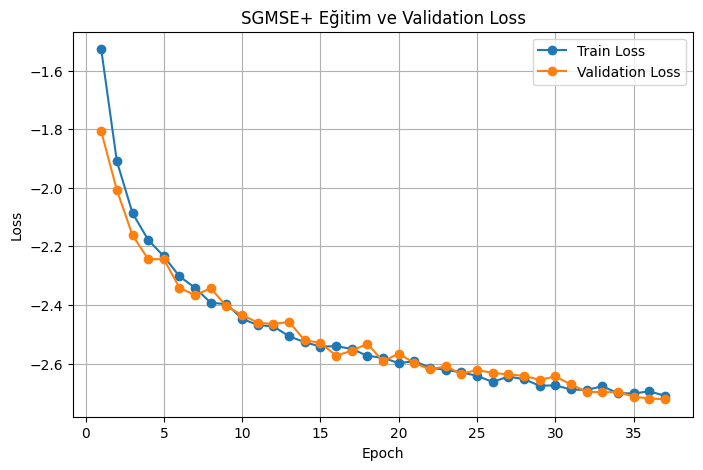

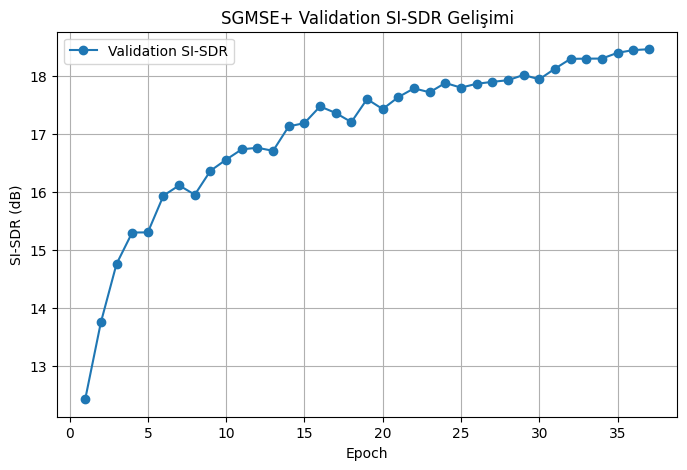

✅ Grafikler oluşturuldu
En iyi epoch: 37
En iyi Validation SI-SDR: 18.465000771113804


In [21]:
# ============================================================
# SGMSE+ Notebook - Hücre 14
# Eğitim grafikleri
# ============================================================

history = ckpt["history"]

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs_range, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SGMSE+ Eğitim ve Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["val_si_sdr"], marker="o", label="Validation SI-SDR")
plt.xlabel("Epoch")
plt.ylabel("SI-SDR (dB)")
plt.title("SGMSE+ Validation SI-SDR Gelişimi")
plt.legend()
plt.grid(True)
plt.show()

best_epoch = int(np.argmax(history["val_si_sdr"]) + 1)
best_sisdr = float(np.max(history["val_si_sdr"]))

print("✅ Grafikler oluşturuldu")
print("En iyi epoch:", best_epoch)
print("En iyi Validation SI-SDR:", best_sisdr)

In [22]:
# ============================================================
# SGMSE+ Notebook - Hücre 15
# Çoklu ses örnekleri
# Noisy / Clean / Enhanced
# ============================================================

from IPython.display import Audio, display

sample_dir = OUT_DIR / "samples"
sample_dir.mkdir(parents=True, exist_ok=True)

NUM_DEMOS = 5
demo_indices = random.sample(range(len(val_ds)), NUM_DEMOS)

for i, idx in enumerate(demo_indices):

    print("\n" + "=" * 60)
    print(f"ÖRNEK {i+1}")
    print("=" * 60)

    sample_noisy, sample_clean = val_ds[idx]

    with torch.no_grad():
        sample_enhanced = enhance_batch(
            sample_noisy.unsqueeze(0)
        ).squeeze(0).cpu()

    noisy_np = sample_noisy.numpy()
    clean_np = sample_clean.numpy()
    enhanced_np = sample_enhanced.numpy()

    noisy_path = sample_dir / f"demo_{i+1}_noisy.wav"
    clean_path = sample_dir / f"demo_{i+1}_clean.wav"
    enhanced_path = sample_dir / f"demo_{i+1}_enhanced_sgmse_plus.wav"

    write_wav(noisy_path, noisy_np, CFG["sample_rate"])
    write_wav(clean_path, clean_np, CFG["sample_rate"])
    write_wav(enhanced_path, enhanced_np, CFG["sample_rate"])

    print("🔊 Gürültülü:")
    display(Audio(noisy_np, rate=CFG["sample_rate"]))

    print("🎯 Temiz Referans:")
    display(Audio(clean_np, rate=CFG["sample_rate"]))

    print("✨ SGMSE+ Çıktısı:")
    display(Audio(enhanced_np, rate=CFG["sample_rate"]))

print("\n✅ Ses örnekleri kaydedildi:")
print(sample_dir)


ÖRNEK 1
🔊 Gürültülü:


🎯 Temiz Referans:


✨ SGMSE+ Çıktısı:



ÖRNEK 2
🔊 Gürültülü:


🎯 Temiz Referans:


...

✨ SGMSE+ Çıktısı:



ÖRNEK 5
🔊 Gürültülü:


🎯 Temiz Referans:


✨ SGMSE+ Çıktısı:



✅ Ses örnekleri kaydedildi:
/content/drive/MyDrive/SLESS_SGMSE_PLUS/outputs/samples


In [23]:
# ============================================================
# SGMSE+ Notebook - Hücre 16
# Test metrikleri: SI-SDR, PESQ, STOI
# ============================================================

def torch_si_sdr_value(est_np, ref_np):
    est = torch.tensor(est_np, dtype=torch.float32).unsqueeze(0)
    ref = torch.tensor(ref_np, dtype=torch.float32).unsqueeze(0)
    return float(si_sdr(est, ref).mean().item())


def safe_pesq(clean_np, test_np, sr=16000):
    try:
        clean_np = np.asarray(clean_np, dtype=np.float32).reshape(-1)
        test_np = np.asarray(test_np, dtype=np.float32).reshape(-1)

        L = min(len(clean_np), len(test_np))
        clean_np = clean_np[:L]
        test_np = test_np[:L]

        return float(pesq(sr, clean_np, test_np, "wb"))

    except Exception:
        return np.nan


def safe_stoi(clean_np, test_np, sr=16000):
    try:
        clean_np = np.asarray(clean_np, dtype=np.float32).reshape(-1)
        test_np = np.asarray(test_np, dtype=np.float32).reshape(-1)

        L = min(len(clean_np), len(test_np))
        clean_np = clean_np[:L]
        test_np = test_np[:L]

        return float(stoi(clean_np, test_np, sr, extended=False))

    except Exception:
        return np.nan


eval_n = min(CFG["eval_items"], len(val_ds))

rows = []

for i in tqdm(range(eval_n), desc="SGMSE+ metrik hesaplanıyor"):

    noisy, clean = val_ds[i]

    with torch.no_grad():
        enhanced = enhance_batch(
            noisy.unsqueeze(0)
        ).squeeze(0).cpu()

    noisy_np = noisy.numpy()
    clean_np = clean.numpy()
    enhanced_np = enhanced.numpy()

    noisy_sisdr = torch_si_sdr_value(noisy_np, clean_np)
    enhanced_sisdr = torch_si_sdr_value(enhanced_np, clean_np)

    rows.append({
        "sample": i,
        "noisy_si_sdr": noisy_sisdr,
        "enhanced_si_sdr": enhanced_sisdr,
        "si_sdr_improvement": enhanced_sisdr - noisy_sisdr,

        "pesq_noisy": safe_pesq(clean_np, noisy_np, CFG["sample_rate"]),
        "pesq_enhanced": safe_pesq(clean_np, enhanced_np, CFG["sample_rate"]),

        "stoi_noisy": safe_stoi(clean_np, noisy_np, CFG["sample_rate"]),
        "stoi_enhanced": safe_stoi(clean_np, enhanced_np, CFG["sample_rate"]),
    })

metrics_df = pd.DataFrame(rows)

summary = {
    "model": "SGMSE+",
    "eval_items": eval_n,

    "noisy_si_sdr_mean": float(metrics_df["noisy_si_sdr"].mean()),
    "enhanced_si_sdr_mean": float(metrics_df["enhanced_si_sdr"].mean()),
    "si_sdr_improvement_mean": float(metrics_df["si_sdr_improvement"].mean()),

    "pesq_noisy_mean": float(metrics_df["pesq_noisy"].mean()),
    "pesq_enhanced_mean": float(metrics_df["pesq_enhanced"].mean()),

    "stoi_noisy_mean": float(metrics_df["stoi_noisy"].mean()),
    "stoi_enhanced_mean": float(metrics_df["stoi_enhanced"].mean()),
}

metrics_path = OUT_DIR / "sgmse_plus_metrics_per_sample.csv"
summary_path = OUT_DIR / "sgmse_plus_metrics_summary.json"

metrics_df.to_csv(metrics_path, index=False)

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("✅ Metrikler hesaplandı")
print("CSV:", metrics_path)
print("Summary:", summary_path)

display(metrics_df.head())

print("\nÖzet sonuçlar:")
for k, v in summary.items():
    print(f"{k}: {v}")

SGMSE+ metrik hesaplanıyor:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Metrikler hesaplandı
CSV: /content/drive/MyDrive/SLESS_SGMSE_PLUS/outputs/sgmse_plus_metrics_per_sample.csv
Summary: /content/drive/MyDrive/SLESS_SGMSE_PLUS/outputs/sgmse_plus_metrics_summary.json


,sample,noisy_si_sdr,enhanced_si_sdr,si_sdr_improvement,pesq_noisy,pesq_enhanced,stoi_noisy,stoi_enhanced
0,0,-3.190386,6.819743,10.010129,1.080926,1.260395,0.649844,0.798838
1,1,6.894972,25.739979,18.845007,2.834417,2.973459,0.970157,0.974634
2,2,0.072413,10.377138,10.304725,1.314955,1.747493,0.819531,0.921960
3,3,6.906170,20.900959,13.994789,2.062281,3.750087,0.974582,0.995082
4,4,12.289759,32.354202,20.064444,3.627135,3.753226,0.995590,0.995377



Özet sonuçlar:
model: SGMSE+
eval_items: 200
noisy_si_sdr_mean: 7.502766857575625
enhanced_si_sdr_mean: 18.483618776202203
si_sdr_improvement_mean: 10.980851918626577
pesq_noisy_mean: 1.598335783685272
pesq_enhanced_mean: 2.2875949060497573
stoi_noisy_mean: 0.8659549252539017
stoi_enhanced_mean: 0.9065819045170432


In [24]:
# ============================================================
# SGMSE+ Notebook - Hücre 17
# Nihai sonuç özeti
# ============================================================

final_results = pd.DataFrame([
    {
        "Model": "SGMSE+",
        "SI-SDR Before": summary["noisy_si_sdr_mean"],
        "SI-SDR After": summary["enhanced_si_sdr_mean"],
        "SI-SDR Gain": summary["si_sdr_improvement_mean"],
        "PESQ Before": summary["pesq_noisy_mean"],
        "PESQ After": summary["pesq_enhanced_mean"],
        "STOI Before": summary["stoi_noisy_mean"],
        "STOI After": summary["stoi_enhanced_mean"]
    }
])

display(final_results)

summary_txt = OUT_DIR / "FINAL_RESULTS.txt"

with open(summary_txt, "w", encoding="utf-8") as f:

    f.write("SGMSE+ FINAL RESULTS\n")
    f.write("=" * 50 + "\n\n")

    for k, v in summary.items():
        f.write(f"{k}: {v}\n")

print("✅ Nihai özet oluşturuldu")
print(summary_txt)

,Model,SI-SDR Before,SI-SDR After,SI-SDR Gain,PESQ Before,PESQ After,STOI Before,STOI After
0,SGMSE+,7.502767,18.483619,10.980852,1.598336,2.287595,0.865955,0.906582


✅ Nihai özet oluşturuldu
/content/drive/MyDrive/SLESS_SGMSE_PLUS/outputs/FINAL_RESULTS.txt


In [27]:
# ============================================================
# SGMSE+ Notebook - Hücre 18
# Final backup
# ============================================================

from pathlib import Path
import shutil

ROOT_DIR = Path("/content/drive/MyDrive/SLESS_SGMSE_PLUS")

MODEL_DIR = ROOT_DIR / "models"
OUT_DIR = ROOT_DIR / "outputs"

BEST_MODEL_PATH = MODEL_DIR / "sgmse_plus_best_model.pt"
LAST_MODEL_PATH = MODEL_DIR / "sgmse_plus_last_model.pt"

BACKUP_DIR = ROOT_DIR / "FINAL_BACKUP"

BACKUP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

files_to_copy = [
    BEST_MODEL_PATH,
    LAST_MODEL_PATH,
    OUT_DIR / "sgmse_plus_metrics_per_sample.csv",
    OUT_DIR / "sgmse_plus_metrics_summary.json",
    OUT_DIR / "FINAL_RESULTS.txt"
]

for f in files_to_copy:

    if Path(f).exists():

        shutil.copy2(
            f,
            BACKUP_DIR / Path(f).name
        )

print("✅ Backup tamamlandı")
print(BACKUP_DIR)

print("\nYedeklenen dosyalar:\n")

for f in sorted(BACKUP_DIR.glob("*")):
    print("•", f.name)

✅ Backup tamamlandı
/content/drive/MyDrive/SLESS_SGMSE_PLUS/FINAL_BACKUP

Yedeklenen dosyalar:

• FINAL_RESULTS.txt
• sgmse_plus_best_model.pt
• sgmse_plus_last_model.pt
• sgmse_plus_metrics_per_sample.csv
• sgmse_plus_metrics_summary.json
